In [137]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency


In [ ]:
DATA_DIR = Path("/home/jovyan/Desktop/IDX intern/california")
f = DATA_DIR / "california_sfr_202505_202605.csv"

df = pd.read_csv(f, low_memory=False)
df["source_file"] = f.name
df["CloseDate"] = pd.to_datetime(df["CloseDate"])

print(f"\nTotal shape: {df.shape}")
print(f"Date range: {df['CloseDate'].min()} — {df['CloseDate'].max()}")
print(f"ClosePrice nulls: {df['ClosePrice'].isna().sum()}")


Total shape: (141997, 79)
Date range: 2025-05-01 00:00:00 — 2026-05-31 00:00:00
ClosePrice nulls: 0


In [139]:
df.head()


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file
0,PacificWest,PacificWest,NaN,True,NaN,NaN,False,1800000.0000,1114761060,realtorjinheechoi@hotmail.com,...,7740.0000,1.0000,False,3.0000,Fullerton Joint Union High,92833,310.0000,7740.0000,NaN,california_sfr_202505_202605.csv
1,Malibu,Malibu,"Tile,Wood",True,NaN,True,False,1200000.0000,1114760473,sonia@maisonrealestate.com,...,4697.0000,NaN,False,2.0000,NaN,90065,NaN,4697.0000,NaN,california_sfr_202505_202605.csv
2,Mlslistings,Mlslistings,"Carpet,Laminate",False,NaN,NaN,NaN,NaN,1114744790,dthurro@thurrorealty.com,...,5775.0000,NaN,False,1.0000,Other,95014,NaN,5775.0000,NaN,california_sfr_202505_202605.csv
3,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,False,1425000.0000,1114743101,apreston@grandavenueca.com,...,7500.0000,3.0000,False,2.0000,Placentia-Yorba Linda Unified,92886,124.0000,7500.0000,NaN,california_sfr_202505_202605.csv
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,660000.0000,1114741523,dave.advent@yahoo.com,...,4552.0000,NaN,False,2.0000,NaN,92026,NaN,4552.0000,NaN,california_sfr_202505_202605.csv


In [140]:
print(df.shape)
print(df.dtypes.value_counts())
print(df.head(2))
print(df.columns.tolist())


(141997, 79)
object            47
float64           28
int64              3
datetime64[ns]     1
Name: count, dtype: int64
  BuyerAgentAOR ListAgentAOR   Flooring ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  ListingKey                 ListAgentEmail  ... LotSizeArea  MainLevelBedrooms  \
0   PacificWest  PacificWest        NaN   True          NaN        NaN         False       1800000.0000  1114761060  realtorjinheechoi@hotmail.com  ...   7740.0000             1.0000   
1        Malibu       Malibu  Tile,Wood   True          NaN       True         False       1200000.0000  1114760473     sonia@maisonrealestate.com  ...   4697.0000                NaN   

  NewConstructionYN GarageSpaces          HighSchoolDistrict  PostalCode AssociationFee LotSizeSquareFeet  MiddleOrJuniorSchoolDistrict                       source_file  
0             False       3.0000  Fullerton Joint Union High       92833       310.0000         7740.0000                           NaN  californi

### ClosePrice


In [141]:
target = "ClosePrice"
df["log_price"] = np.where(df["ClosePrice"] > 0, np.log(df["ClosePrice"]), np.nan)
print("ClosePrice <= 0:", (df["ClosePrice"] <= 0).sum())
print("ClosePrice isna:", df["ClosePrice"].isna().sum())
print("log_price inf/-inf:", np.isinf(df["log_price"]).sum())
print("log_price isna:", df["log_price"].isna().sum())


ClosePrice <= 0: 1
ClosePrice isna: 0
log_price inf/-inf: 0
log_price isna: 1


/opt/base-uv/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


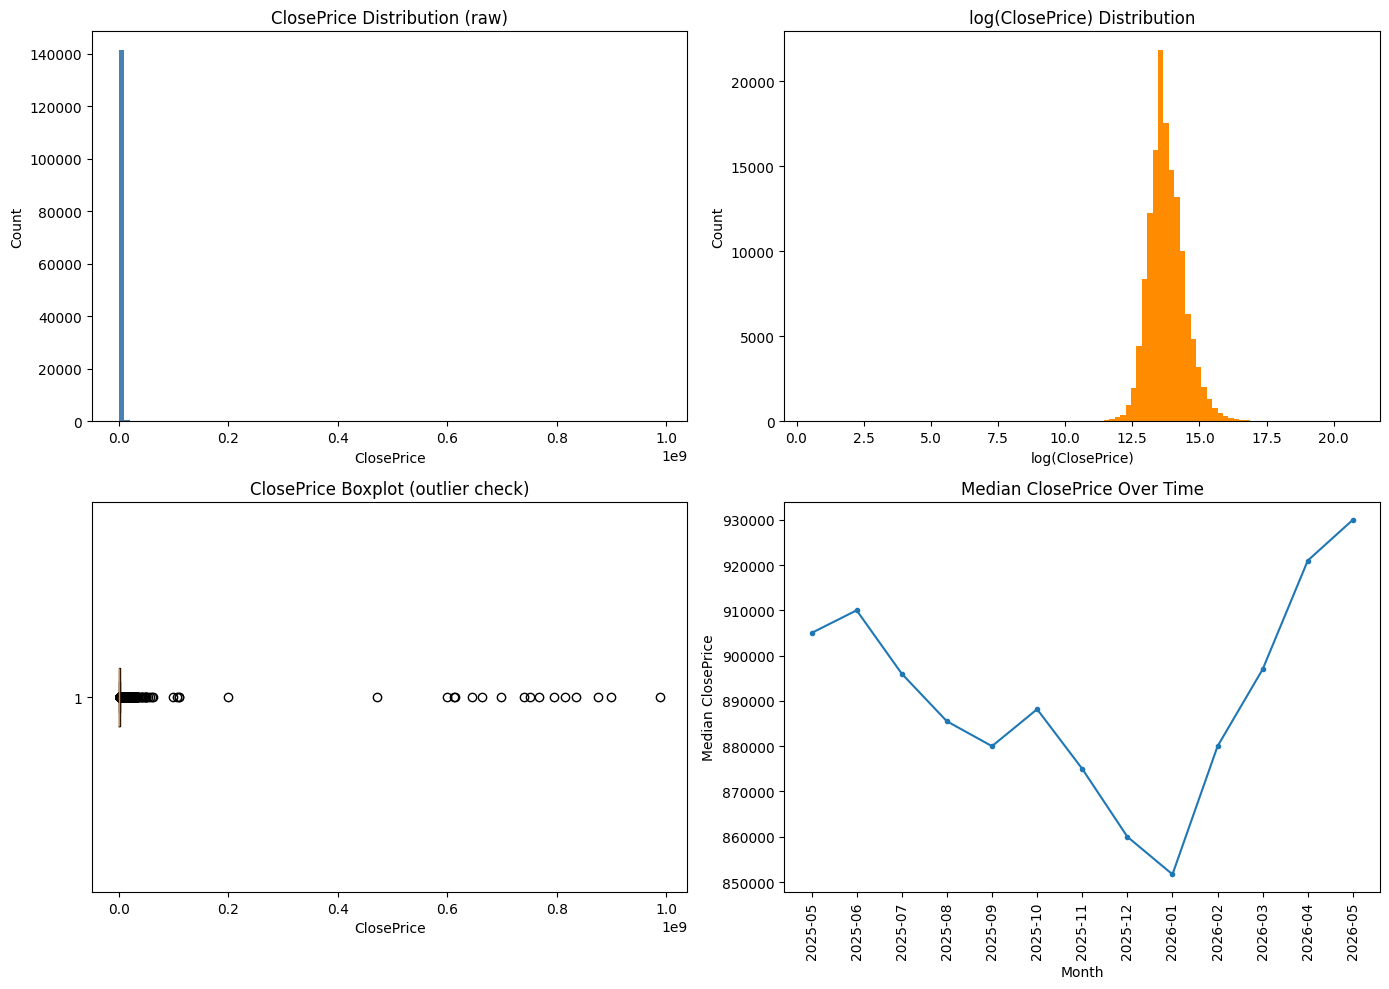

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df["ClosePrice"], bins=100, color="steelblue", edgecolor="none")
axes[0, 0].set_title("ClosePrice Distribution (raw)")
axes[0, 0].set_xlabel("ClosePrice")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(df["log_price"], bins=100, color="darkorange", edgecolor="none")
axes[0, 1].set_title("log(ClosePrice) Distribution")
axes[0, 1].set_xlabel("log(ClosePrice)")
axes[0, 1].set_ylabel("Count")

axes[1, 0].boxplot(df["ClosePrice"].dropna(), vert=False)
axes[1, 0].set_title("ClosePrice Boxplot (outlier check)")
axes[1, 0].set_xlabel("ClosePrice")

monthly_median = df.groupby(df["CloseDate"].dt.to_period("M"))["ClosePrice"].median()
axes[1, 1].plot(
    monthly_median.index.astype(str), monthly_median.values, marker="o", markersize=3
)
axes[1, 1].set_title("Median ClosePrice Over Time")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Median ClosePrice")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [143]:
df["price_ratio"] = df["ClosePrice"] / df["ListPrice"]

suspicious_all = df[(df["price_ratio"] > 1.5) | (df["price_ratio"] < 0.5)].copy()

print(f"Total count: {len(df)}")
print(
    f"ClosePrice/ListPrice Ratio anomaly count: {len(suspicious_all)} ({len(suspicious_all) / len(df) * 100:.3f}%)"
)

check_cols = [
    "ClosePrice",
    "ListPrice",
    "price_ratio",
    "City",
    "CountyOrParish",
    "LivingArea",
    "CloseDate",
    "source_file",
]
available_cols = [c for c in check_cols if c in df.columns]

suspicious_all_sorted = suspicious_all.sort_values("price_ratio", ascending=False)
print(suspicious_all_sorted[available_cols])


Total count: 141997
ClosePrice/ListPrice Ratio anomaly count: 445 (0.313%)
           ClosePrice     ListPrice  price_ratio                  City   CountyOrParish  LivingArea  CloseDate                       source_file
47465  751412000.0000   699000.0000    1074.9814               La Mesa        San Diego    798.0000 2025-09-26  california_sfr_202505_202605.csv
127822 768500000.0000   750000.0000    1024.6667             San Diego        San Diego   1444.0000 2026-04-09  california_sfr_202505_202605.csv
60956  989500000.0000   979000.0000    1010.7252              Valencia      Los Angeles   2289.0000 2025-10-31  california_sfr_202505_202605.csv
55862  815000000.0000   809000.0000    1007.4166                Saugus      Los Angeles   1900.0000 2025-09-10  california_sfr_202505_202605.csv
77731  740000000.0000   735000.0000    1006.8027             San Diego        San Diego   1271.0000 2025-11-24  california_sfr_202505_202605.csv
124610 645000000.0000   645000.0000    1000.0000       

In [144]:
pd.set_option("display.float_format", "{:.4f}".format)
df["price_ratio"] = df["ClosePrice"] / df["ListPrice"]

print(df["price_ratio"].describe())
print(
    df["price_ratio"].quantile(
        [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.5, 0.99, 0.995, 0.999, 0.9995, 0.9999]
    )
)


count   141997.0000
mean         1.1109
std         10.2053
min          0.0000
25%          0.9735
50%          1.0000
75%          1.0169
max       1074.9814
Name: price_ratio, dtype: float64
0.0001     0.0970
0.0005     0.5109
0.0010     0.6438
0.0050     0.7857
0.0100     0.8333
0.5000     1.0000
0.9900     1.2741
0.9950     1.3819
0.9990     1.6849
0.9995     1.9681
0.9999   735.5117
Name: price_ratio, dtype: float64


In [145]:
lower_cap = df["price_ratio"].quantile(0.005)  # 0.79
upper_cap = df["price_ratio"].quantile(0.9995)  # 1.97

# Filter out remaining anomalies
df_clean = df[
    (df["price_ratio"] >= lower_cap) & (df["price_ratio"] <= upper_cap)
].copy()

print(f"Before cleaning: {len(df)}, After cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")


Before cleaning: 141997, After cleaning: 141218
Rows removed: 779


### Location & Neighborhood features

In [146]:
location_features = [
    "Latitude",
    "Longitude",
    "latfilled",
    "lonfilled",
    "UnparsedAddress",
    "StreetNumberNumeric",
    "City",
    "StateOrProvince",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "SubdivisionName",
    "ElementarySchool",
    "MiddleOrJuniorSchool",
    "HighSchool",
    "ElementarySchoolDistrict",
    "MiddleOrJuniorSchoolDistrict",
    "HighSchoolDistrict",
]

results = []

for col in location_features:
    if col not in df_clean.columns:
        results.append(
            {
                "feature": col,
                "type": "missing_col",
                "missing_pct": None,
                "n_unique": None,
                "score": None,
                "note": "not in df",
            }
        )
        continue

    missing_pct = df_clean[col].isna().mean() * 100
    n_unique = df_clean[col].nunique(dropna=True)

    if pd.api.types.is_numeric_dtype(df_clean[col]):
        valid = df_clean[[col, "log_price"]].dropna()
        if len(valid) > 10:
            corr, p = stats.pearsonr(valid[col], valid["log_price"])
        else:
            corr, p = np.nan, np.nan
        results.append(
            {
                "feature": col,
                "type": "numeric",
                "missing_pct": round(missing_pct, 1),
                "n_unique": n_unique,
                "score": round(corr, 4) if pd.notna(corr) else None,
                "p_value": p,
                "note": "correlation w/ log_price",
            }
        )
    else:
        valid = df_clean[[col, "log_price"]].dropna()
        if n_unique < 2 or n_unique > 5000 or len(valid) < 30:
            results.append(
                {
                    "feature": col,
                    "type": "categorical",
                    "missing_pct": round(missing_pct, 1),
                    "n_unique": n_unique,
                    "score": None,
                    "p_value": None,
                    "note": "skipped (too high/low cardinality)",
                }
            )
            continue
        groups = [g["log_price"].values for _, g in valid.groupby(col) if len(g) >= 5]
        if len(groups) < 2:
            f_stat, p = np.nan, np.nan
        else:
            f_stat, p = stats.f_oneway(*groups)
        results.append(
            {
                "feature": col,
                "type": "categorical",
                "missing_pct": round(missing_pct, 1),
                "n_unique": n_unique,
                "score": round(f_stat, 2) if pd.notna(f_stat) else None,
                "p_value": p,
                "note": "ANOVA F-stat on log_price",
            }
        )

result_df = pd.DataFrame(results).sort_values("missing_pct")
pd.set_option("display.max_rows", None)
result_df


,feature,type,missing_pct,n_unique,score,p_value,note
0,Latitude,numeric,0.0000,133473.0000,-0.0587,0.0000,correlation w/ log_price
1,Longitude,numeric,0.0000,135376.0000,-0.0906,0.0000,correlation w/ log_price
6,City,categorical,0.0000,1004.0000,444.9700,0.0000,ANOVA F-stat on log_price
7,StateOrProvince,categorical,0.0000,5.0000,NaN,NaN,ANOVA F-stat on log_price
8,PostalCode,categorical,0.0000,2149.0000,391.2400,0.0000,ANOVA F-stat on log_price
9,CountyOrParish,categorical,0.0000,60.0000,1627.2200,0.0000,ANOVA F-stat on log_price
4,UnparsedAddress,categorical,0.1000,139571.0000,NaN,NaN,skipped (too high/low cardinality)
5,StreetNumberNumeric,numeric,0.1000,33701.0000,-0.0871,0.0000,correlation w/ log_price
10,MLSAreaMajor,categorical,14.7000,1025.0000,267.9300,0.0000,ANOVA F-stat on log_price
17,HighSchoolDistrict,categorical,27.0000,427.0000,462.2800,0.0000,ANOVA F-stat on log_price


In [147]:
MISSING_PCT_THRESHOLD = 80
MAX_CARDINALITY = 5000
MIN_CARDINALITY = 2


def apply_feature_decision(row):
    feature = row["feature"]
    missing_pct = row["missing_pct"]
    n_unique = row["n_unique"]
    p_value = row["p_value"]
    ftype = row["type"]

    if row["type"] == "missing_col":
        return "drop_not_in_dataset"

    if pd.notna(missing_pct) and missing_pct >= 100:
        return "drop_all_missing"

    if pd.notna(n_unique) and n_unique < MIN_CARDINALITY:
        return "drop_no_variance"

    if ftype == "categorical" and pd.notna(n_unique) and n_unique > MAX_CARDINALITY:
        if pd.notna(missing_pct) and missing_pct >= 50:
            return "drop_high_card_high_missing"
        return "drop_id_like"

    if pd.notna(missing_pct) and missing_pct >= MISSING_PCT_THRESHOLD:
        return "drop_high_missing"

    if feature == "StreetNumberNumeric":
        return "drop_no_causal_meaning"

    if pd.isna(p_value):
        return "drop_not_significant"
    if p_value >= 0.05:
        return "drop_not_significant"

    return "keep"


result_df["decision"] = result_df.apply(apply_feature_decision, axis=1)
pd.set_option("display.width", 200)
kept_df = result_df.loc[
    result_df["decision"] == "keep",
    ["feature", "type", "missing_pct", "n_unique", "score", "p_value", "decision"],
]
print(kept_df)

location_features_final = kept_df["feature"].tolist()
print("\nFinal features:", location_features_final)

               feature         type  missing_pct    n_unique     score  p_value decision
0             Latitude      numeric       0.0000 133473.0000   -0.0587   0.0000     keep
1            Longitude      numeric       0.0000 135376.0000   -0.0906   0.0000     keep
6                 City  categorical       0.0000   1004.0000  444.9700   0.0000     keep
8           PostalCode  categorical       0.0000   2149.0000  391.2400   0.0000     keep
9       CountyOrParish  categorical       0.0000     60.0000 1627.2200   0.0000     keep
10        MLSAreaMajor  categorical      14.7000   1025.0000  267.9300   0.0000     keep
17  HighSchoolDistrict  categorical      27.0000    427.0000  462.2800   0.0000     keep

Final features: ['Latitude', 'Longitude', 'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor', 'HighSchoolDistrict']


# EDA

## Geographic distribution

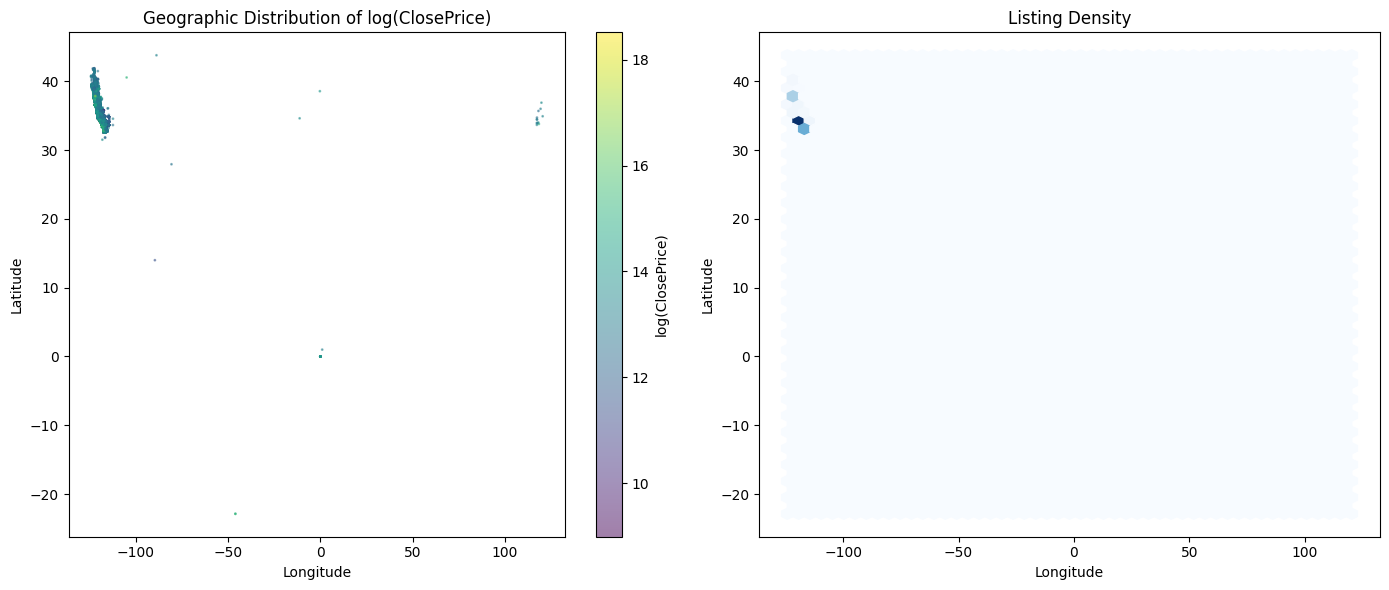

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df_clean["Longitude"],
    df_clean["Latitude"],
    c=df_clean["log_price"],
    cmap="viridis",
    s=1,
    alpha=0.5,
)
axes[0].set_title("Geographic Distribution of log(ClosePrice)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="log(ClosePrice)")

axes[1].hexbin(df_clean["Longitude"], df_clean["Latitude"], gridsize=50, cmap="Blues")
axes[1].set_title("Listing Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()


In [149]:
# Check for coordinates outside California's valid range
# California roughly: lat 32-42, lon -125 to -114
invalid_coords = df_clean[
    (df_clean["Latitude"] < 31.0)
    | (df_clean["Latitude"] > 45)
    | (df_clean["Longitude"] < -125.0)
    | (df_clean["Longitude"] > -113.5)
]
print(f"Invalid coordinate count: {len(invalid_coords)}")
print(
    invalid_coords[
        ["Latitude", "Longitude", "City", "CountyOrParish", "ClosePrice"]
    ].head(20)
)


Invalid coordinate count: 40
       Latitude  Longitude                  City   CountyOrParish   ClosePrice
11248   40.5556  -104.9546                   NaN            Other 4050000.0000
21161   27.9429   -80.6551                 Other            Other  325000.0000
21929   34.4800   117.3100           Victorville   San Bernardino  490000.0000
22182    1.0000     1.0000              Beaumont        Riverside  511000.0000
35136    0.0000     0.0000             Los Gatos      Santa Clara 3517000.0000
39759   38.5628    -0.2626        Mountain House      San Joaquin 1240000.0000
43012   33.8006   118.3901  Palos Verdes Estates      Los Angeles 3100000.0000
46849   33.6408  -112.3711                   NaN            Other  299500.0000
51461    0.0000     0.0000               Salinas         Monterey 1200000.0000
54683   36.0000   119.3000               Visalia           Tulare  489000.0000
58068   36.8931   119.7605                Fresno           Fresno  785000.0000
60596   34.6195   -11.2

### Detect longitude sign-flip errors: latitude is valid CA range, longitude is positive but would be valid CA range if negated

In [150]:
sign_flip_mask = (
    (df_clean["Latitude"] >= 32)
    & (df_clean["Latitude"] <= 42)
    & (df_clean["Longitude"] > 0)
    & (-df_clean["Longitude"] >= -125)
    & (-df_clean["Longitude"] <= -114)
)
print(f"Sign-flip fixable count: {sign_flip_mask.sum()}")
print(df_clean.loc[sign_flip_mask, ["Latitude", "Longitude", "City", "CountyOrParish"]])
df_clean.loc[sign_flip_mask, "Longitude"] = -df_clean.loc[sign_flip_mask, "Longitude"]


Sign-flip fixable count: 12
        Latitude  Longitude                  City  CountyOrParish
21929    34.4800   117.3100           Victorville  San Bernardino
43012    33.8006   118.3901  Palos Verdes Estates     Los Angeles
54683    36.0000   119.3000               Visalia          Tulare
58068    36.8931   119.7605                Fresno          Fresno
74905    34.0187   118.0658           Pico Rivera     Los Angeles
75811    34.9169   120.4327           Santa Maria   Santa Barbara
77499    33.6677   117.2708         Lake Elsinore       Riverside
78084    33.9373   117.2601         Moreno Valley       Riverside
92789    34.4231   117.3663              Hesperia  San Bernardino
98934    35.6911   118.1400             Lancaster     Los Angeles
120968   33.9207   117.4675             Riverside       Riverside
121904   34.7287   117.3431             Helendale  San Bernardino


In [151]:
still_invalid = df_clean[
    (df_clean["Latitude"] < 31.0)
    | (df_clean["Latitude"] > 45)
    | (df_clean["Longitude"] < -125.0)
    | (df_clean["Longitude"] > -113.5)
]
print(
    still_invalid[
        ["Latitude", "Longitude", "City", "CountyOrParish", "ClosePrice"]
    ].head(20)
)

        Latitude  Longitude            City   CountyOrParish   ClosePrice
11248    40.5556  -104.9546             NaN            Other 4050000.0000
21161    27.9429   -80.6551           Other            Other  325000.0000
22182     1.0000     1.0000        Beaumont        Riverside  511000.0000
35136     0.0000     0.0000       Los Gatos      Santa Clara 3517000.0000
39759    38.5628    -0.2626  Mountain House      San Joaquin 1240000.0000
46849    33.6408  -112.3711             NaN            Other  299500.0000
51461     0.0000     0.0000         Salinas         Monterey 1200000.0000
60596    34.6195   -11.2303        Palmdale      Los Angeles  816000.0000
65791    34.5596  -112.3463           Other            Other  599000.0000
70409    13.9982   -89.6413           Other  Foreign Country   90000.0000
85917    43.7844   -88.7879          Pomona      Los Angeles  590000.0000
87018     0.0000     0.0000          Marina         Monterey 1532264.0000
90393     0.0000     0.0000        Pal

In [152]:
df_clean = df_clean[~df_clean.index.isin(still_invalid.index)].copy()
print(f"Final row count: {len(df_clean)}")


Final row count: 141190


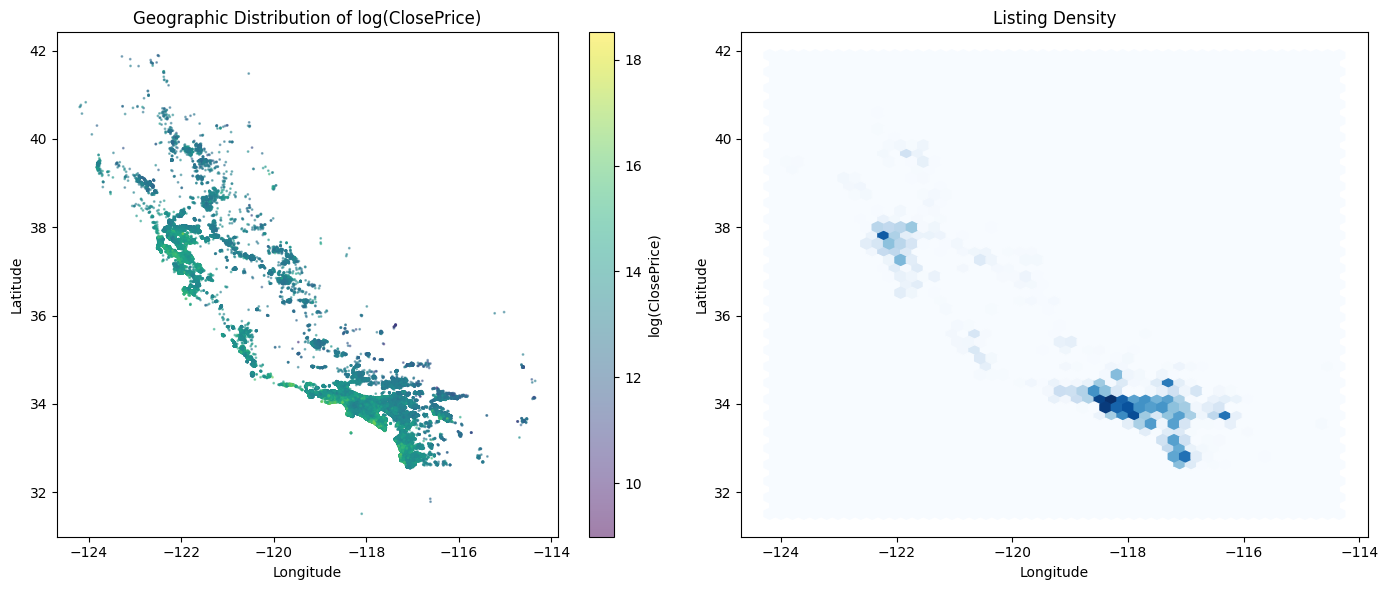

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter = axes[0].scatter(
    df_clean["Longitude"],
    df_clean["Latitude"],
    c=df_clean["log_price"],
    cmap="viridis",
    s=1,
    alpha=0.5,
)
axes[0].set_title("Geographic Distribution of log(ClosePrice)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(scatter, ax=axes[0], label="log(ClosePrice)")

axes[1].hexbin(df_clean["Longitude"], df_clean["Latitude"], gridsize=50, cmap="Blues")
axes[1].set_title("Listing Density")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()


## Price distribution by county

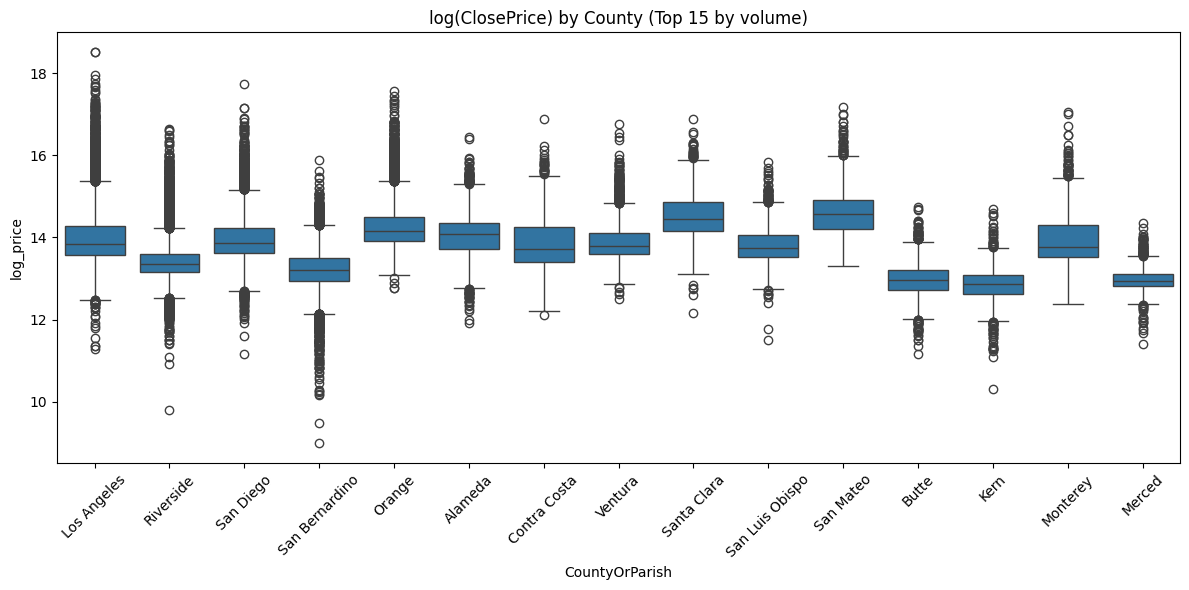

In [154]:
top_counties = df_clean["CountyOrParish"].value_counts().head(15).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_clean[df_clean["CountyOrParish"].isin(top_counties)],
    x="CountyOrParish",
    y="log_price",
    ax=ax,
    order=df_clean.groupby("CountyOrParish")["log_price"]
    .median()
    .sort_values(ascending=False)
    .loc[top_counties]
    .index,
)
ax.set_title("log(ClosePrice) by County (Top 15 by volume)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## Missing value pattern

In [159]:
for col in ["MLSAreaMajor", "HighSchoolDistrict"]:
    missing_by_county = df_clean.groupby("CountyOrParish")[col].apply(
        lambda x: x.isna().mean() * 100
    )
    print(f"\nTop 20 counties with highest missing rate for {col}:")
    print(missing_by_county.sort_values(ascending=False).head(20))



Top 20 counties with highest missing rate for MLSAreaMajor:
CountyOrParish
Other           100.0000
Clark           100.0000
Trinity         100.0000
Sutter          100.0000
Amador          100.0000
San Francisco    98.6607
Contra Costa     97.8520
Butte            96.9907
Calaveras        95.0000
Merced           94.7863
Alameda          94.7144
Tuolumne         93.8776
Glenn            93.4132
Yuba             93.1034
Siskiyou         93.1034
Yolo             91.1765
Kings            90.1515
Solano           87.9433
Lassen           87.5000
Colusa           87.5000
Name: MLSAreaMajor, dtype: float64

Top 20 counties with highest missing rate for HighSchoolDistrict:
CountyOrParish
Other          100.0000
Mono           100.0000
Amador          90.9091
Trinity         88.2353
Mendocino       84.5361
Solano          82.6241
Yolo            76.4706
Sonoma          75.5102
Contra Costa    73.2697
Marin           72.0930
San Joaquin     70.9191
Napa            70.4545
Placer          67.

## Multicollinearity check

--- Latitude vs Longitude correlation ---
           Latitude  Longitude
Latitude     1.0000    -0.9252
Longitude   -0.9252     1.0000

--- Cramer's V Matrix (categorical-categorical association) ---
                     City  PostalCode  CountyOrParish  MLSAreaMajor  HighSchoolDistrict
City               1.0000      0.9100          0.9700        0.7200              0.7500
PostalCode         0.9100      1.0000          0.9800        0.7000              0.7600
CountyOrParish     0.9700      0.9800          1.0000        0.6400              0.7600
MLSAreaMajor       0.7200      0.7000          0.6400        1.0000              0.6100
HighSchoolDistrict 0.7500      0.7600          0.7600        0.6100              1.0000


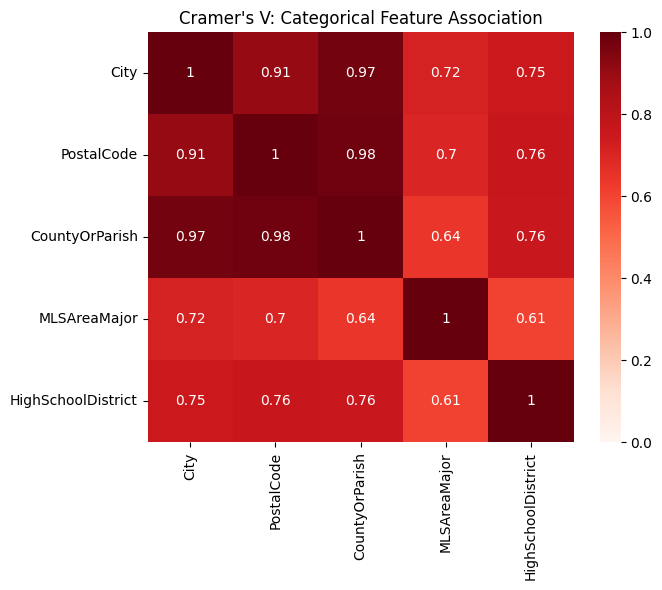

In [157]:
# Numeric x numeric
print("--- Latitude vs Longitude correlation ---")
print(df_clean[["Latitude", "Longitude"]].corr())


# Categorical x categorical: Cramer's V
def cramers_v(x, y):
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    confusion_matrix = pd.crosstab(valid["x"], valid["y"])
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


cat_cols = [
    "City",
    "PostalCode",
    "CountyOrParish",
    "MLSAreaMajor",
    "HighSchoolDistrict",
]
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            cramers_matrix.loc[c1, c2] = 1.0
        else:
            cramers_matrix.loc[c1, c2] = cramers_v(df_clean[c1], df_clean[c2])

print("\n--- Cramer's V Matrix (categorical-categorical association) ---")
print(cramers_matrix.round(2))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cramers_matrix.astype(float), annot=True, cmap="Reds", vmin=0, vmax=1, ax=ax
)
ax.set_title("Cramer's V: Categorical Feature Association")
plt.tight_layout()
plt.show()


In [158]:
# Numeric x categorical: correlation ratio (eta)
def correlation_ratio(categories, values):
    valid = pd.DataFrame({"cat": categories, "val": values}).dropna()
    fcat, _ = pd.factorize(valid["cat"])
    cat_num = np.max(fcat) + 1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(cat_num):
        cat_measures = valid["val"][fcat == i]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.mean(cat_measures)
    y_total_avg = np.sum(y_avg_array * n_array) / np.sum(n_array)
    numerator = np.sum(n_array * (y_avg_array - y_total_avg) ** 2)
    denominator = np.sum((valid["val"] - y_total_avg) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0


print("--- Correlation Ratio (Latitude/Longitude vs categorical) ---")
for num_col in ["Latitude", "Longitude"]:
    for cat_col in cat_cols:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        print(f"  {num_col} vs {cat_col}: eta = {eta:.3f}")


--- Correlation Ratio (Latitude/Longitude vs categorical) ---
  Latitude vs City: eta = 0.999
  Latitude vs PostalCode: eta = 1.000
  Latitude vs CountyOrParish: eta = 0.995
  Latitude vs MLSAreaMajor: eta = 0.909
  Latitude vs HighSchoolDistrict: eta = 0.967
  Longitude vs City: eta = 0.999
  Longitude vs PostalCode: eta = 1.000
  Longitude vs CountyOrParish: eta = 0.989
  Longitude vs MLSAreaMajor: eta = 0.907
  Longitude vs HighSchoolDistrict: eta = 0.963
